In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('ushape.csv')

In [8]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [11]:
df.rename(columns={'3.159499363321345566e-02':'x','9.869877579082642072e-01':'y','0.000000000000000000e+00':'class'},inplace=True)
df.head()

,x,y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [15]:
x=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

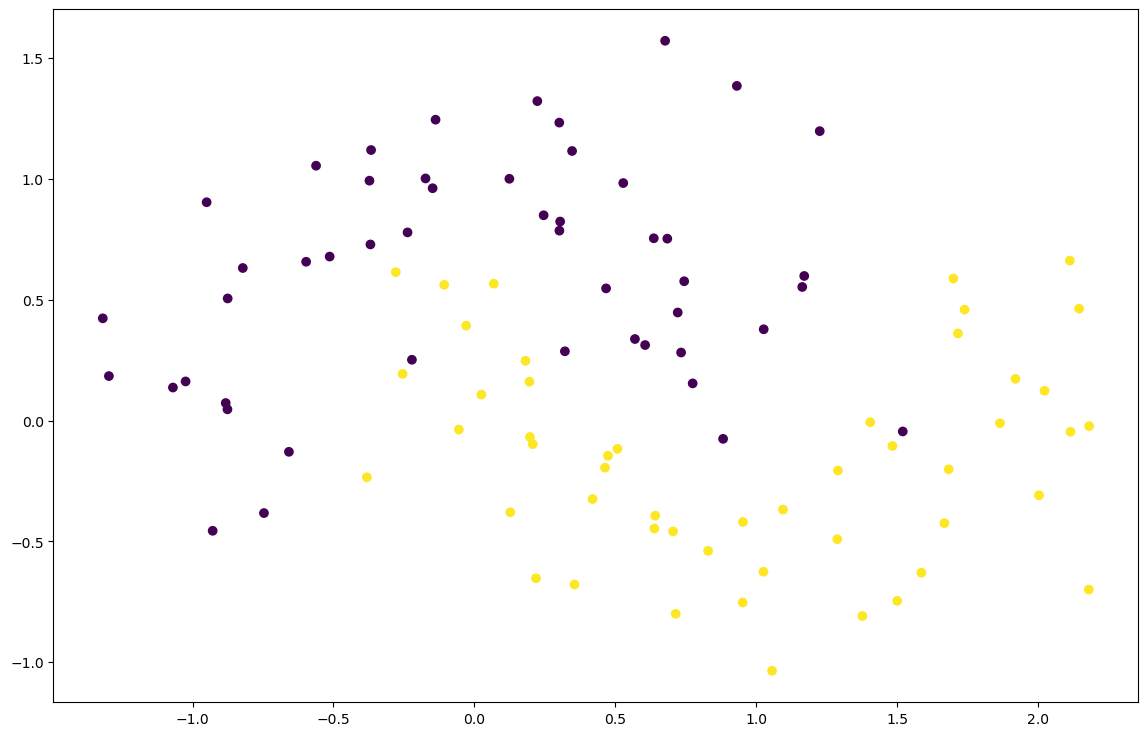

In [16]:
plt.figure(figsize=(14,9))
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lor=LogisticRegression()

In [19]:
lor.fit(x,y)

LogisticRegression()

<Axes: >

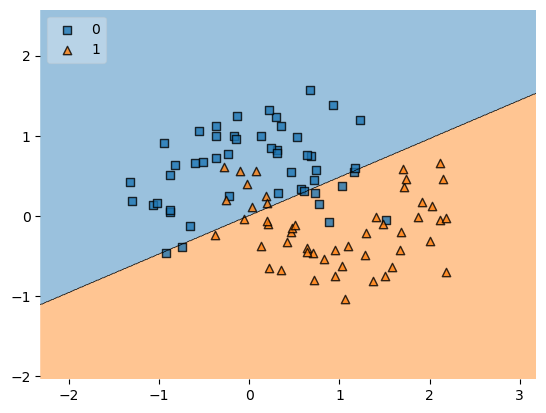

In [23]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x,y.astype('int'),lor,legend=2)

In [24]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(lor,x,y,scoring='accuracy',cv=10))

np.float64(0.8300000000000001)

In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3,include_bias=False)
x_trf=poly.fit_transform(x)

In [26]:
lor1=LogisticRegression()
np.mean(cross_val_score(lor1,x_trf,y,scoring='accuracy',cv=10))

np.float64(0.9099999999999999)

In [29]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    lor = LogisticRegression()
    lor.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(lor,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=lor.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

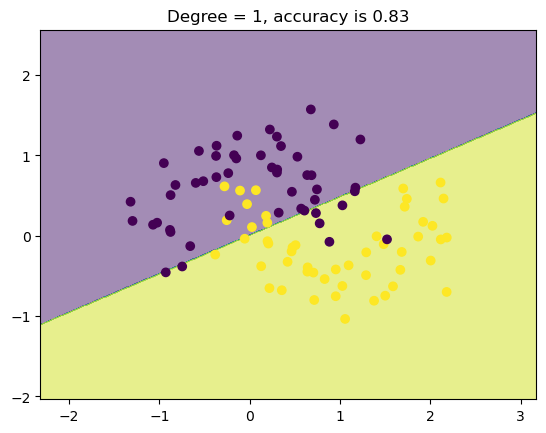

In [33]:
plot_decision_boundary(x,y,1)

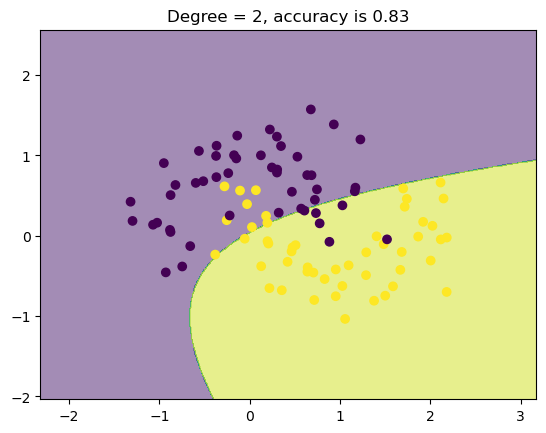

In [34]:
plot_decision_boundary(x,y,2)

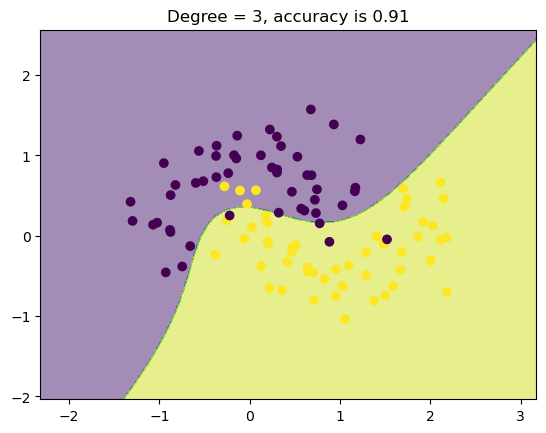

In [35]:
plot_decision_boundary(x,y,3)

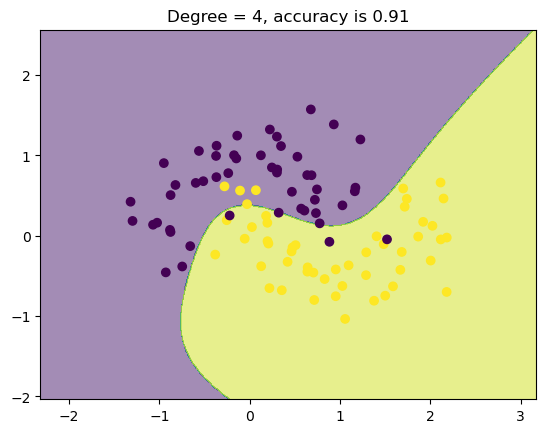

In [36]:
plot_decision_boundary(x,y,4)

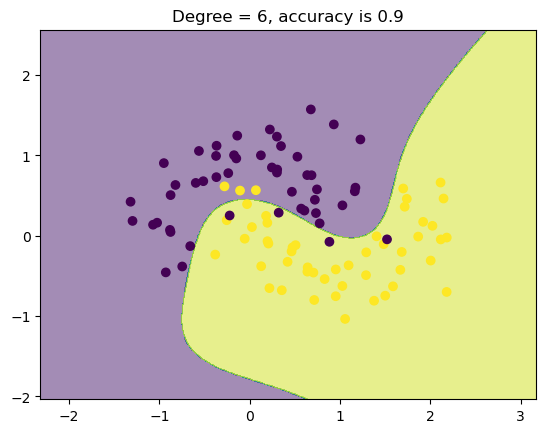

In [37]:
plot_decision_boundary(x,y,6)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

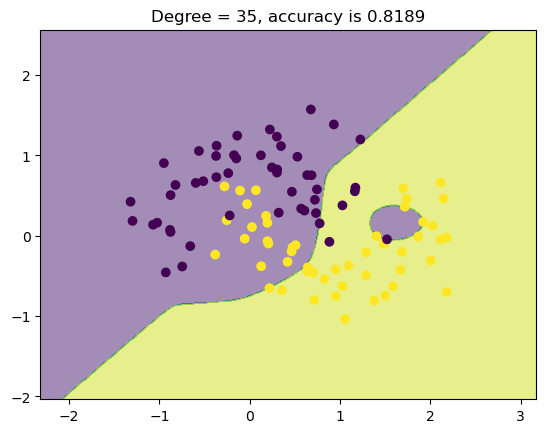

In [38]:
plot_decision_boundary(x,y,35)

# lower the degree -> case of underfitting can occur
# higher the degree -> case of overfitiing can occur